In [1]:
import pandas as pd
import numpy as np
import pickle
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import pandas as pd

from src.metrics import dice_coef
from src.confidence import (SoftDice, MeanMaxConfidence,ExpectedEntropy,Median_min_max,Quantile_thresh, Patch_Level_Aggregation)
from src.utils import write_aurc_curves, write_aurc_curves_by_min_coverage, plot_aurc_curves, thresh_alpha, adjust_axis_limits
def format_func(value, _):
    return f"{value:.2f}"

 Parameters used to construct the graphics in the paper.

In [2]:
plt.style.use(['science'])
plt.rcParams['text.usetex'] = False
plt.rcParams['image.cmap'] = 'bwr'
#plt.rcParams['axes.grid'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams.update({'font.size': 9})
colors = [plt.colormaps['tab20'](i) for i in range(20)]

markersize = 3
styles = dict(
random=dict(linestyle='--', color='gray', label="Random"),
amsp=dict(color=colors[0], markersize=markersize, marker="v"),
ane=dict(color=colors[1], markersize=markersize, marker="p"),
mmmc=dict(color=colors[2], markersize=markersize, marker="D"),
tla=dict(color=colors[3], markersize=markersize, marker="^"),
pla=dict(color=colors[4], markersize=markersize, marker="o"),
sdc=dict(color=colors[5], markersize=markersize, marker="s"),
aef=dict(color=colors[6], markersize=markersize, marker="*"),
aef_sdc=dict(color=colors[7], markersize=markersize, marker="h"),
oracle=dict(linestyle=':',color='gray', markersize=markersize, label="Oracle"),
idc_true=dict(color=colors[9], marker="*", zorder=-2),
idc_hat=dict(color=colors[10], markersize=markersize+2, marker=".", zorder=-1),
)

Variables used to compose the tables

In [3]:
rc_curves = {} # RCs curves
aurcs_all = {} # AURCS
aurcs_min_05_all = {} # AURCs computed above 50% coverage
prevails = {} #Forground ratio

## RC curve template

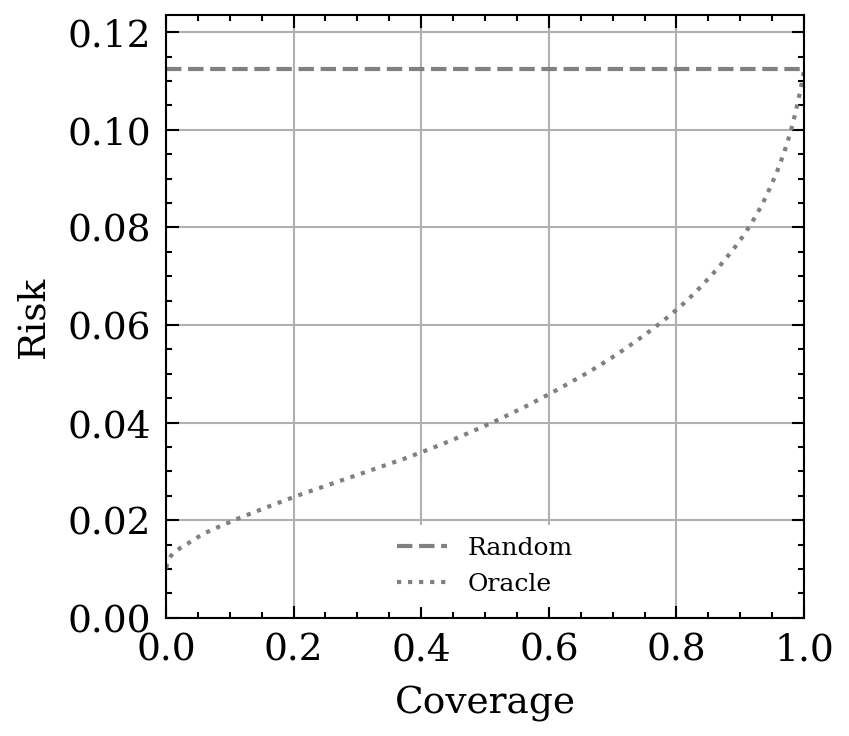

In [4]:
data = np.load('./data/isic.npz')

y = data['y']
p_hat = data['p_hat']

# Guarantee that we will be working only with images that have predictions
zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

# Generating the RC curve template    
confidence_metrics = {
}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=0.5) for i in range(len(y))])
dice_errors = 1 - dice_scores

aurcs = write_aurc_curves(confidences, dice_errors)
aurcs_min_05 = write_aurc_curves_by_min_coverage(confidences, dice_errors)
fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)

y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)

ax.legend(loc='lower center')

ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/template_RC.pdf", format="pdf")
fig.show()



# ISIC RC curve

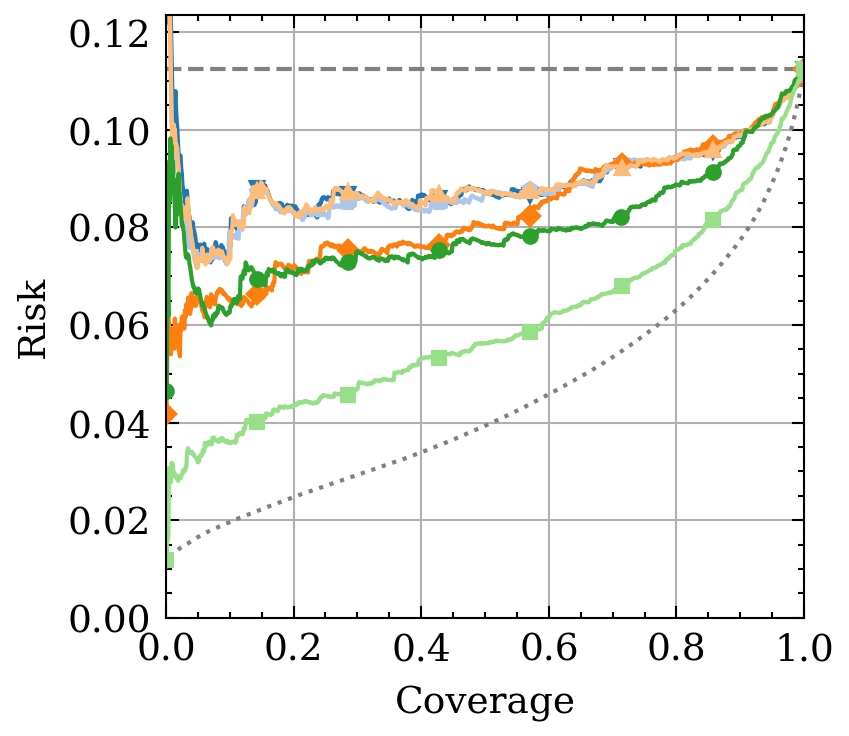

In [5]:
data = np.load('./data/isic.npz')

y = data['y']
p_hat = data['p_hat']

# Guarantee that we will be working only with images that have predictions
zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

# Calculate the hyperparameter alpha for TLA using the full test set
threshold_alpha = thresh_alpha(p_hat, threshold = 0.5)
    
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(0.5),
}

confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=0.5) for i in range(len(y))])
dice_errors = 1 - dice_scores

aurcs = write_aurc_curves(confidences, dice_errors)
aurcs_min_05 = write_aurc_curves_by_min_coverage(confidences, dice_errors)
fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)
y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)
plt.gca().get_legend().set_visible(False)
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/ISIC_RC.pdf", format="pdf")
fig.show()

aurcs_all['isic'] = aurcs
aurcs_min_05_all['isic'] = aurcs_min_05


In [6]:
# Calculating target foreground ratio
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['isic'] = np.mean(prevail)

In [7]:
# Calculating prediction foreground ratio
prevail = []
for p_hat_i in (p_hat>0.5):
    prevail.append(np.mean(p_hat_i.squeeze()))
prevails['isic - predicted foreground proportion'] = np.mean(prevail)

In [8]:
rc_curves['isic'] = {'confidences':confidences, 'dice_errors':dice_errors}

# BRaTS RC curve

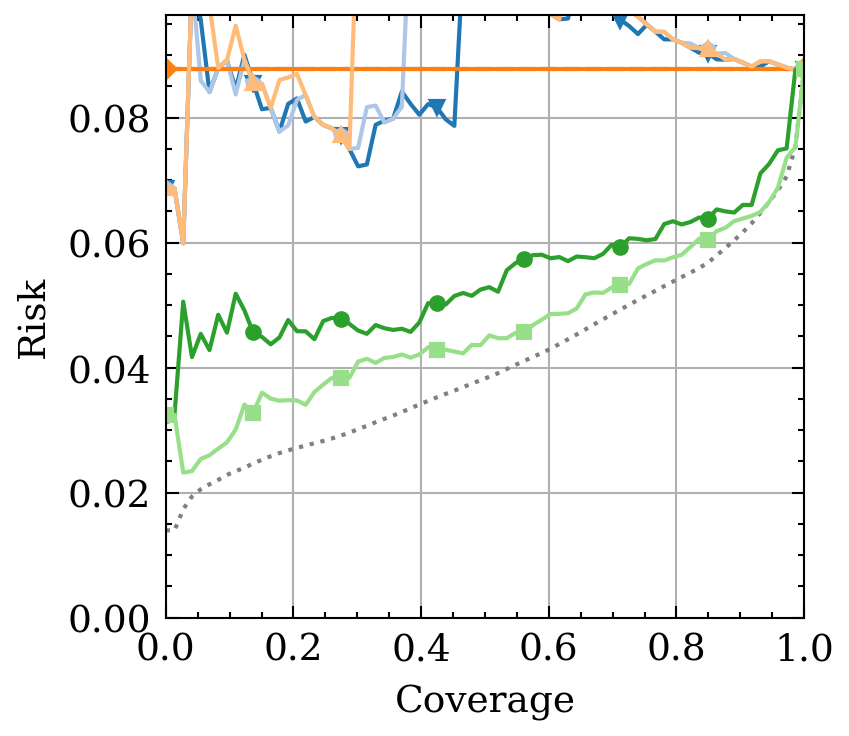

In [9]:
data = np.load('./data/brats.npz')

y = data['y']
p_hat = data['p_hat']
y_hat = data['y_hat']

# Guarantee that we will be working only with images that have predictions
zero_preds = np.all(y == 0, axis=(-3,-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]
y_hat = y_hat[~zero_preds]

threshold_alpha = thresh_alpha(y_hat)
    
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
}

# In this case we will compute SDC considering that we have both p_hat and y_hat
confidence_metric_sdc = SoftDice(0.5)
# Preallocate outputs
confidences = {name: [] for name in confidence_metrics}
confidences['SDC'] = []

# Single pass over the batch
for p_hat_i,y_hat_i in zip(p_hat, y_hat):
    # Compute all per-prediction metrics in one go
    for name, metric in confidence_metrics.items():
        confidences[name].append(metric(p_hat_i))
    # SDC needs y_hat
    confidences['SDC'].append(confidence_metric_sdc(p_hat_i, y_hat=y_hat_i))

# Dice errors computed from y_hat and y
dice_scores = np.stack([dice_coef(y_hat[i], y[i]) for i in range(len(y))])
dice_errors = 1 - dice_scores


aurcs = write_aurc_curves(confidences, dice_errors)
aurcs_min_05 = write_aurc_curves_by_min_coverage(confidences, dice_errors)
fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)

y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)

plt.gca().get_legend().set_visible(False)
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/BRATS_RC.pdf", format="pdf")
fig.show()

aurcs_all['brats'] = aurcs
aurcs_min_05_all['brats'] = aurcs_min_05

In [10]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['brats'] = np.mean(prevail)

In [11]:
prevail = []
for y_hat_i in (y_hat>0.5):
    prevail.append(np.mean(y_hat_i.squeeze()))
prevails['brats - predicted foreground proportion'] = np.mean(prevail)

In [12]:
rc_curves['brats'] = {'confidences':confidences, 'dice_errors':dice_errors}

# MSWML-ID RC curve

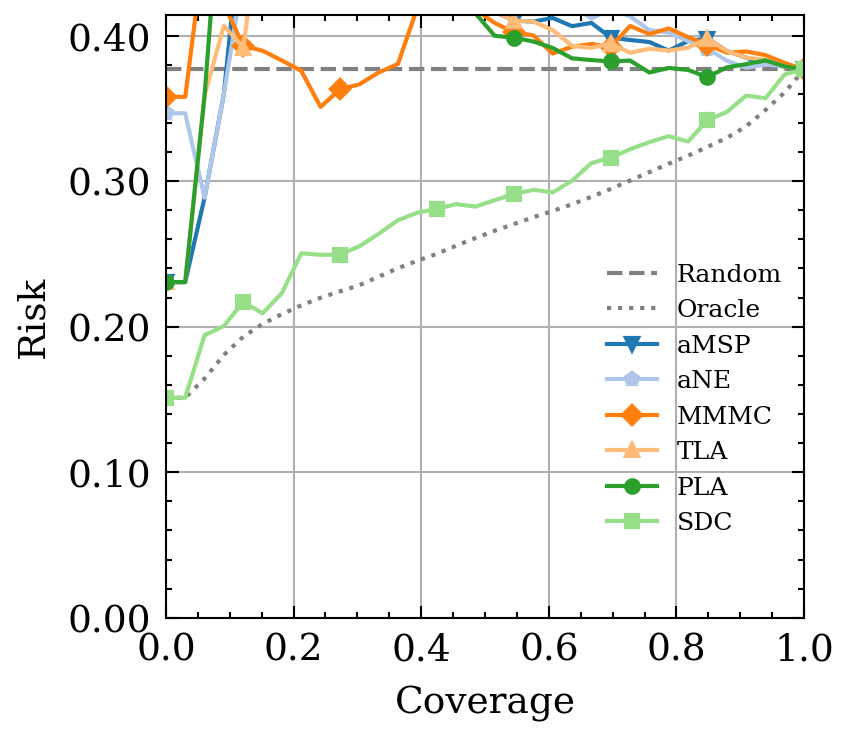

In [13]:
# MSWML have predictions with different shapes
with open('./data/mswml/eval_in_predictions.pkl', 'rb') as file:
    # Save the list to the file
    p_hat =  pickle.load(file)

with open('./data/mswml/eval_in_gt.pkl', 'rb') as file:
    # Save the list to the file
    y =  pickle.load(file)

threshold_alpha = thresh_alpha(p_hat, threshold = 0.35)
    
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(0.35),

}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=0.35) for i in range(len(y))])
dice_errors = 1 - dice_scores

aurcs = write_aurc_curves(confidences, dice_errors)
aurcs_min_05 = write_aurc_curves_by_min_coverage(confidences, dice_errors)
fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)

y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)

ax.legend(loc='lower right', ncol=1, frameon=False, bbox_to_anchor=(1.0, 0.1)) 

ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/MSWML_RC.pdf", format="pdf")
fig.show()

aurcs_all['mswml'] = aurcs
aurcs_min_05_all['mswml'] = aurcs_min_05

In [14]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['mswml'] = np.mean(prevail)

In [15]:
prevail = []
for p_hat_i in p_hat:
    prevail.append(np.mean((p_hat_i>0.35).squeeze()))
prevails['mswml - predicted foreground proportion'] = np.mean(prevail)

In [16]:
rc_curves['mswml'] = {'confidences':confidences, 'dice_errors':dice_errors}

# Polyp-ID RC curve

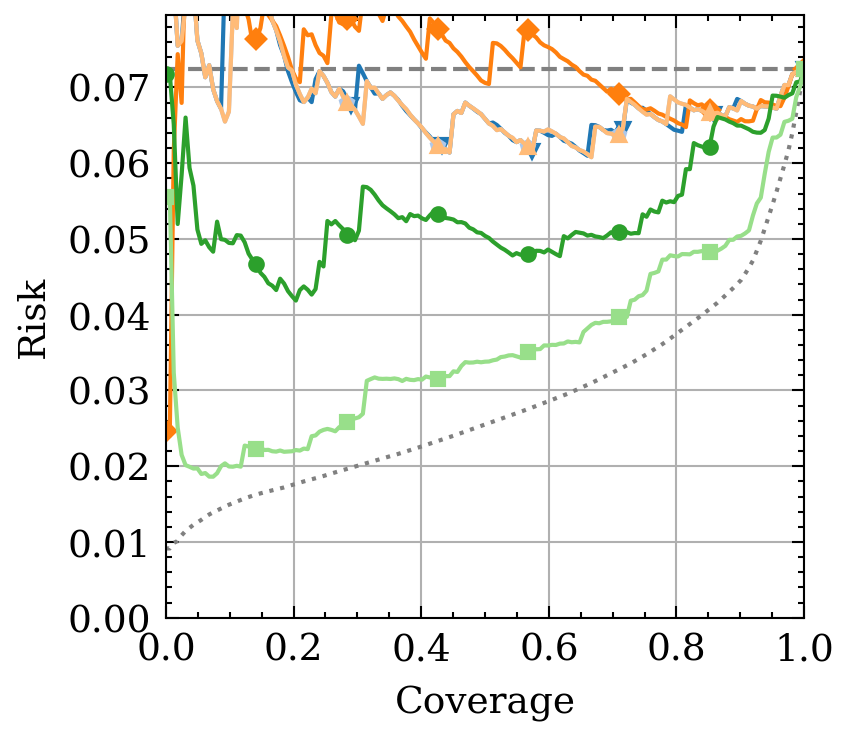

In [17]:
data = np.load('./data/polyp.npz')

y = data['y']
p_hat = data['p_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

threshold_alpha = thresh_alpha(p_hat, threshold = 0.5)
    
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(0.5),
}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=0.5) for i in range(len(y))])
dice_errors = 1 - dice_scores

aurcs = write_aurc_curves(confidences, dice_errors)
aurcs_min_05 = write_aurc_curves_by_min_coverage(confidences, dice_errors)
fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)

y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)
plt.gca().get_legend().set_visible(False)
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/POLYP-PVT_RC.pdf", format="pdf")
fig.show()

aurcs_all['polyp'] = aurcs
aurcs_min_05_all['polyp'] = aurcs_min_05

In [18]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['polyp'] = np.mean(prevail)

In [19]:
prevail = []
for p_hat_i in p_hat:
    prevail.append(np.mean((p_hat_i>0.5).squeeze()))
prevails['polyp - predicted foreground proportion'] = np.mean(prevail)

In [20]:
rc_curves['polyp'] = {'confidences':confidences, 'dice_errors':dice_errors}

# Optic Cup-ID RC curve

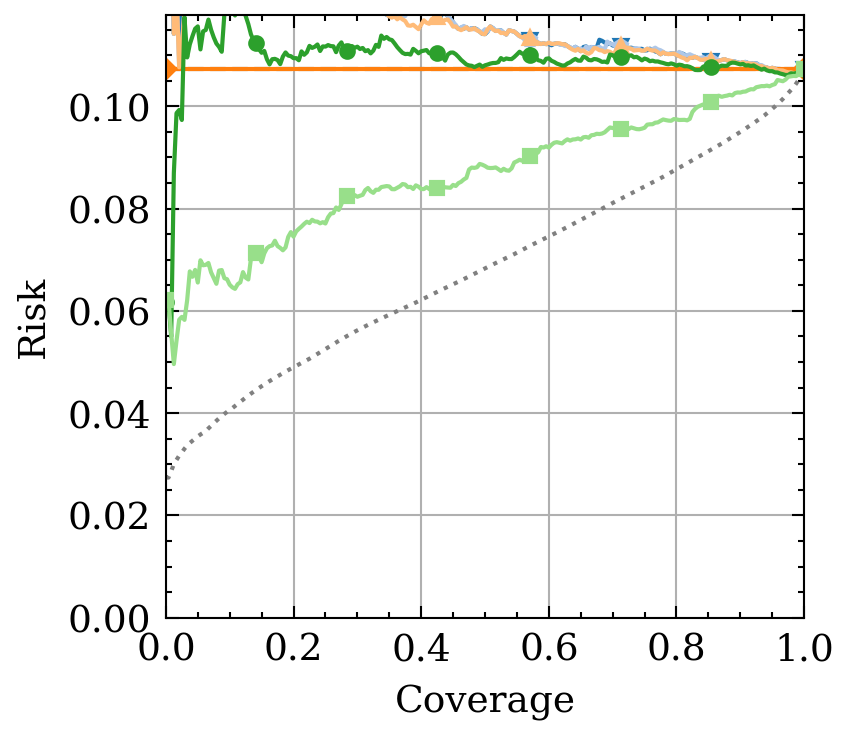

In [21]:
data = np.load('./data/optic_cup.npz')

y = data['y']
p_hat = data['p_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

threshold_alpha = thresh_alpha(p_hat, threshold = 0.5)
    
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(0.5),
}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=0.5) for i in range(len(y))])
dice_errors = 1 - dice_scores

aurcs = write_aurc_curves(confidences, dice_errors)
aurcs_min_05 = write_aurc_curves_by_min_coverage(confidences, dice_errors)
fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)
y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
plt.gca().get_legend().set_visible(False)
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/OPTIC_CUP_RC.pdf", format="pdf")
fig.show()

aurcs_all['optic_cup'] = aurcs
aurcs_min_05_all['optic_cup'] = aurcs_min_05

In [22]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['optic_cup'] = np.mean(prevail)

In [23]:
prevail = []
for p_hat_i in p_hat:
    prevail.append(np.mean((p_hat_i>0.5).squeeze()))
prevails['optic_cup - predicted foreground proportion'] = np.mean(prevail)

In [24]:
rc_curves['optic_cup'] = {'confidences':confidences, 'dice_errors':dice_errors}

# BUSI RC curve

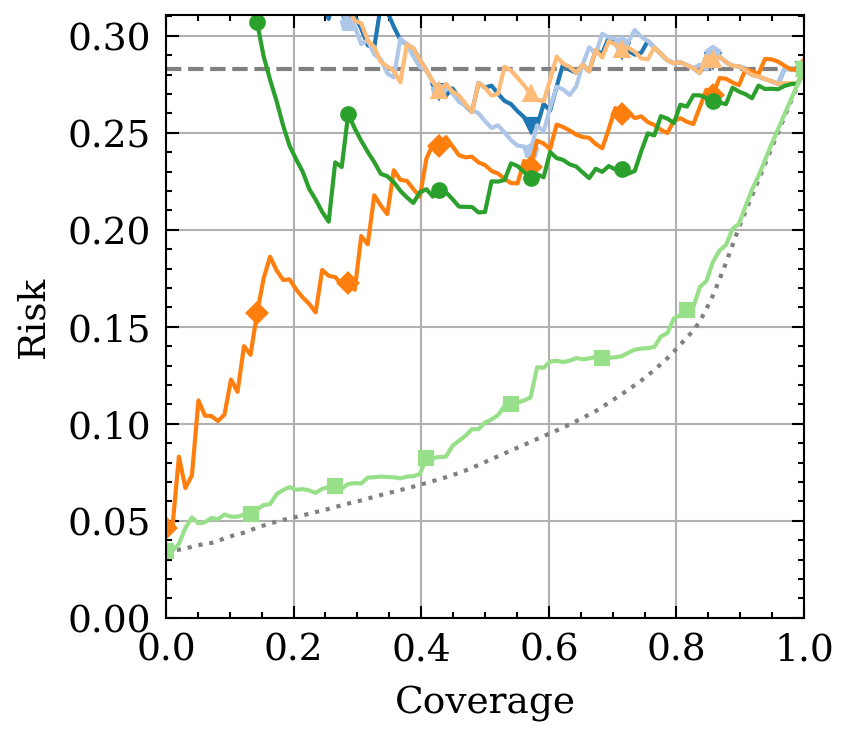

In [25]:
data = np.load('./data/busi.npz')

y = data['y']
p_hat = data['p_hat']

zero_preds = np.all(y == 0, axis=(-2,-1)).flatten()
p_hat= p_hat[~zero_preds]
y = y[~zero_preds]

threshold_alpha = thresh_alpha(p_hat, threshold = 0.5)
    
confidence_metrics = {
    'aMSP': MeanMaxConfidence(),
    'aNE': ExpectedEntropy(),
    'MMMC':Median_min_max(),
    'TLA':Quantile_thresh(threshold_alpha),
    'PLA':Patch_Level_Aggregation(),
    'SDC': SoftDice(0.5),
}
confidences = {name: [confidence_metric(p_hat_i) for p_hat_i in p_hat]
               for name, confidence_metric in confidence_metrics.items()}

dice_scores = np.stack([dice_coef(p_hat[i], y[i],threshold=0.5) for i in range(len(y))])
dice_errors = 1 - dice_scores

aurcs = write_aurc_curves(confidences, dice_errors)
aurcs_min_05 = write_aurc_curves_by_min_coverage(confidences, dice_errors)
fig, ax = plt.subplots()
ax = plot_aurc_curves(confidences, dice_errors, ax)
y_min, y_max = adjust_axis_limits(np.mean(dice_errors))

ax.set_ylim(y_min, y_max)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
plt.gca().get_legend().set_visible(False)
ax.set_ylabel('Risk')
ax.set_xlabel('Coverage')
ax.yaxis.set_major_formatter(FuncFormatter(format_func))
fig.tight_layout()
fig.savefig("./graphs/BUSI_RC.pdf", format="pdf")
fig.show()

aurcs_all['busi'] = aurcs
aurcs_min_05_all['busi'] = aurcs_min_05

In [26]:
prevail = []
for y_i in y:
    prevail.append(np.mean(y_i.squeeze()))
prevails['busi'] = np.mean(prevail)

In [27]:
prevail = []
for p_hat_i in p_hat:
    prevail.append(np.mean((p_hat_i>0.5).squeeze()))
prevails['busi - predicted foreground proportion'] = np.mean(prevail)

In [28]:
rc_curves['busi'] = {'confidences':confidences, 'dice_errors':dice_errors}

In [29]:
with open('rc_curves_data.pkl', "wb") as file:
    pickle.dump(rc_curves, file)

In [30]:
with open('aurcs_data.pkl', "wb") as file:
    pickle.dump(aurcs_all, file)

In [31]:
def dataframe_to_latex(df, caption, label, index):
    """
    Convert a pandas DataFrame to a transposed LaTeX tabular string with numeric values rounded to 4 decimal places.

    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        caption (str): Caption for the table.
        label (str): Label for the table.
        index (str): Header label for the first column (which now contains the original column names).

    Returns:
        str: A string containing the LaTeX table.
    """
    # Transpose the DataFrame so that rows become columns and vice versa.
    df = df.transpose()

    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    # There is one extra column for the row labels.
    latex_table += "\\begin{tabular}{" + " | ".join(["c"] * (len(df.columns) + 1)) + "}\n"
    latex_table += "\\hline\n"

    # The header row: the first cell is the provided label, then the column headers
    # (which are now the original DataFrame's index values).
    latex_table += f"{index} & " + " & ".join(str(col) for col in df.columns) + " \\\\\n"
    latex_table += "\\hline\n"

    # Iterate over the transposed rows (which correspond to the original DataFrame's columns)
    for idx, row in df.iterrows():
        # The first cell is the row header (the original column name)
        formatted_row = [str(idx)]
        # Format each cell: if numeric, round to 4 decimals; otherwise, use its string representation.
        formatted_row.extend(
            f"{x:.3f}" if isinstance(x, (int, float)) else str(x)
            for x in row.values
        )
        latex_table += " & ".join(formatted_row) + " \\\\\n"
        latex_table += "\\hline\n"

    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{" + caption + "}\n"
    latex_table += "\\label{tab:" + label + "}\n"
    latex_table += "\\end{table}\n"

    return latex_table

In [32]:
print(dataframe_to_latex(pd.DataFrame(aurcs_all), caption='AURCS of ID data for non trainable confidence estimators', label='aurcs_d_table', index= 'Confidence estimator'))

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c | c | c | c | c | c}
\hline
Confidence estimator & Random & Ideal & aMSP & aNE & MMMC & TLA & PLA & SDC \\
\hline
isic & 0.112 & 0.044 & 0.090 & 0.089 & 0.082 & 0.090 & 0.080 & 0.059 \\
\hline
brats & 0.088 & 0.040 & 0.089 & 0.092 & 0.088 & 0.096 & 0.055 & 0.046 \\
\hline
mswml & 0.377 & 0.262 & 0.414 & 0.418 & 0.394 & 0.412 & 0.408 & 0.282 \\
\hline
polyp & 0.072 & 0.028 & 0.069 & 0.069 & 0.074 & 0.069 & 0.054 & 0.036 \\
\hline
optic_cup & 0.107 & 0.068 & 0.119 & 0.118 & 0.107 & 0.118 & 0.109 & 0.087 \\
\hline
busi & 0.283 & 0.100 & 0.359 & 0.343 & 0.216 & 0.353 & 0.289 & 0.114 \\
\hline
\end{tabular}
\caption{AURCS of ID data for non trainable confidence estimators}
\label{tab:aurcs_d_table}
\end{table}



In [33]:
from collections import defaultdict

confidences_choosen = ['aMSP','SDC']

cofidences_div_by_random_aurcs = defaultdict(dict)

for task in aurcs_all.keys():
    cofidences_div_by_random_aurcs[task]['True foreground proportion'] = prevails[task]
    cofidences_div_by_random_aurcs[task]['Predicted foreground proportion'] = prevails[task+' - predicted foreground proportion']
    for confidence in confidences_choosen:
        cofidences_div_by_random_aurcs[task][confidence] = aurcs_all[task][confidence]/aurcs_all[task]['Random']

In [34]:
df_aurc_prev = pd.DataFrame(cofidences_div_by_random_aurcs).T.loc[['isic','polyp','busi', 'optic_cup', 'brats', 'mswml']].rename(columns={'aMSP':'aMSP (AURC)','PLL':'PLL (AURC)'})

In [35]:
from collections import defaultdict

confidences_choosen = ['aMSP','SDC']

cofidences_div_by_random_aurcs50 = defaultdict(dict)

for task in aurcs_all.keys():
    for confidence in confidences_choosen:
        cofidences_div_by_random_aurcs50[task][confidence] = aurcs_min_05_all[task][confidence]/aurcs_all[task]['Random']

In [36]:
df_aurc_prev50 = pd.DataFrame(cofidences_div_by_random_aurcs50).T.loc[['isic','polyp','busi', 'optic_cup', 'brats', 'mswml']].rename(columns={'aMSP':'aMSP (AURC-50%)','PLL':'PLL (AURC-50%)'})

In [37]:
pd.concat([df_aurc_prev, df_aurc_prev50], axis=1)

,True foreground proportion,Predicted foreground proportion,aMSP (AURC),SDC,aMSP (AURC-50%),SDC
isic,0.239206,0.229320,0.800065,0.528692,0.417609,0.331007
polyp,0.123097,0.118875,0.957430,0.495715,0.454236,0.311017
busi,0.091510,0.067409,1.269119,0.404128,0.497108,0.286355
optic_cup,0.043308,0.040117,1.105509,0.808315,0.516116,0.451762
brats,0.011437,0.010983,1.010272,0.529825,0.529693,0.318572
mswml,0.001018,0.000889,1.097598,0.748276,0.510839,0.420056


In [38]:
def naurc(aurcs_all, task, confidence):
    return (aurcs_all[task][confidence] - aurcs_all[task]['Ideal']) / (aurcs_all[task]['Random'] - aurcs_all[task]['Ideal'])